## **Clasificación utilizando LightGBM (LGBM) (Core)**

**Objetivo**

Implementar un pipeline completo de machine learning para un problema de clasificación utilizando LightGBM (LGBM). Se hará especial énfasis en el Análisis Exploratorio de Datos (EDA), preprocesamiento, entrenamiento del modelo y optimización de hiperparámetros.

**Dataset: Loan Prediction Dataset**

**Descripción del Dataset:** El dataset de predicción de préstamos contiene información sobre solicitantes de préstamos, como sus ingresos, historial crediticio y otras características personales. El objetivo es predecir si un solicitante será aprobado para un préstamo basándose en estos factores.

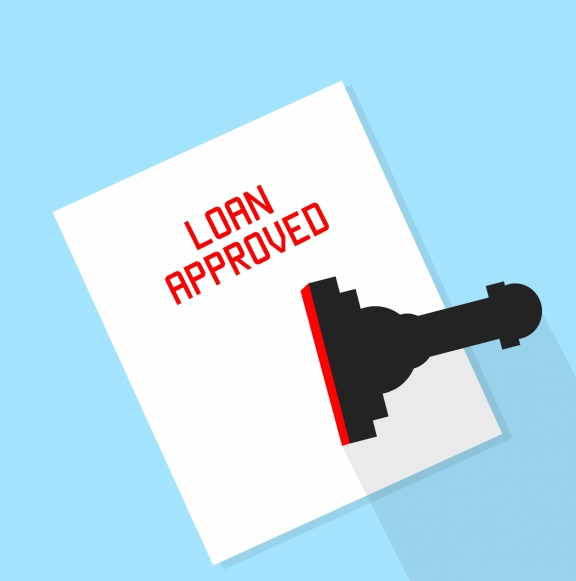

**Instrucciones:**

**Parte 1:** Carga y Exploración Inicial de Datos

**Carga del Dataset:**
* Cargar el dataset desde Kaggle.
* Exploración Inicial:


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_csv('../data/train.csv')

# Exploración de datos
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB
None


**Exploración Inicial:**
* Revisar la estructura del dataset.
* Describir las variables y su distribución.
* Identificar y documentar valores faltantes y outliers.


In [3]:
# Estructura del dataset
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB
None


In [4]:
# Primeras filas
print(df.head().T)

                          0         1         2             3         4
Loan_ID            LP001002  LP001003  LP001005      LP001006  LP001008
Gender                 Male      Male      Male          Male      Male
Married                  No       Yes       Yes           Yes        No
Dependents                0         1         0             0         0
Education          Graduate  Graduate  Graduate  Not Graduate  Graduate
Self_Employed            No        No       Yes            No        No
ApplicantIncome        5849      4583      3000          2583      6000
CoapplicantIncome       0.0    1508.0       0.0        2358.0       0.0
LoanAmount              NaN     128.0      66.0         120.0     141.0
Loan_Amount_Term      360.0     360.0     360.0         360.0     360.0
Credit_History          1.0       1.0       1.0           1.0       1.0
Property_Area         Urban     Rural     Urban         Urban     Urban
Loan_Status               Y         N         Y             Y   

In [5]:
# Resumen estadístico
print(df.describe(include='all'))

         Loan_ID Gender Married Dependents Education Self_Employed  \
count        614    601     611        599       614           582   
unique       614      2       2          4         2             2   
top     LP002990   Male     Yes          0  Graduate            No   
freq           1    489     398        345       480           500   
mean         NaN    NaN     NaN        NaN       NaN           NaN   
std          NaN    NaN     NaN        NaN       NaN           NaN   
min          NaN    NaN     NaN        NaN       NaN           NaN   
25%          NaN    NaN     NaN        NaN       NaN           NaN   
50%          NaN    NaN     NaN        NaN       NaN           NaN   
75%          NaN    NaN     NaN        NaN       NaN           NaN   
max          NaN    NaN     NaN        NaN       NaN           NaN   

        ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
count        614.000000         614.000000  592.000000         600.00000   
unique 

In [6]:
# Valores únicos por columna
print(df.nunique())

Loan_ID              614
Gender                 2
Married                2
Dependents             4
Education              2
Self_Employed          2
ApplicantIncome      505
CoapplicantIncome    287
LoanAmount           203
Loan_Amount_Term      10
Credit_History         2
Property_Area          3
Loan_Status            2
dtype: int64


In [7]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


**Descripción de las variables y su distribución
Visualización**

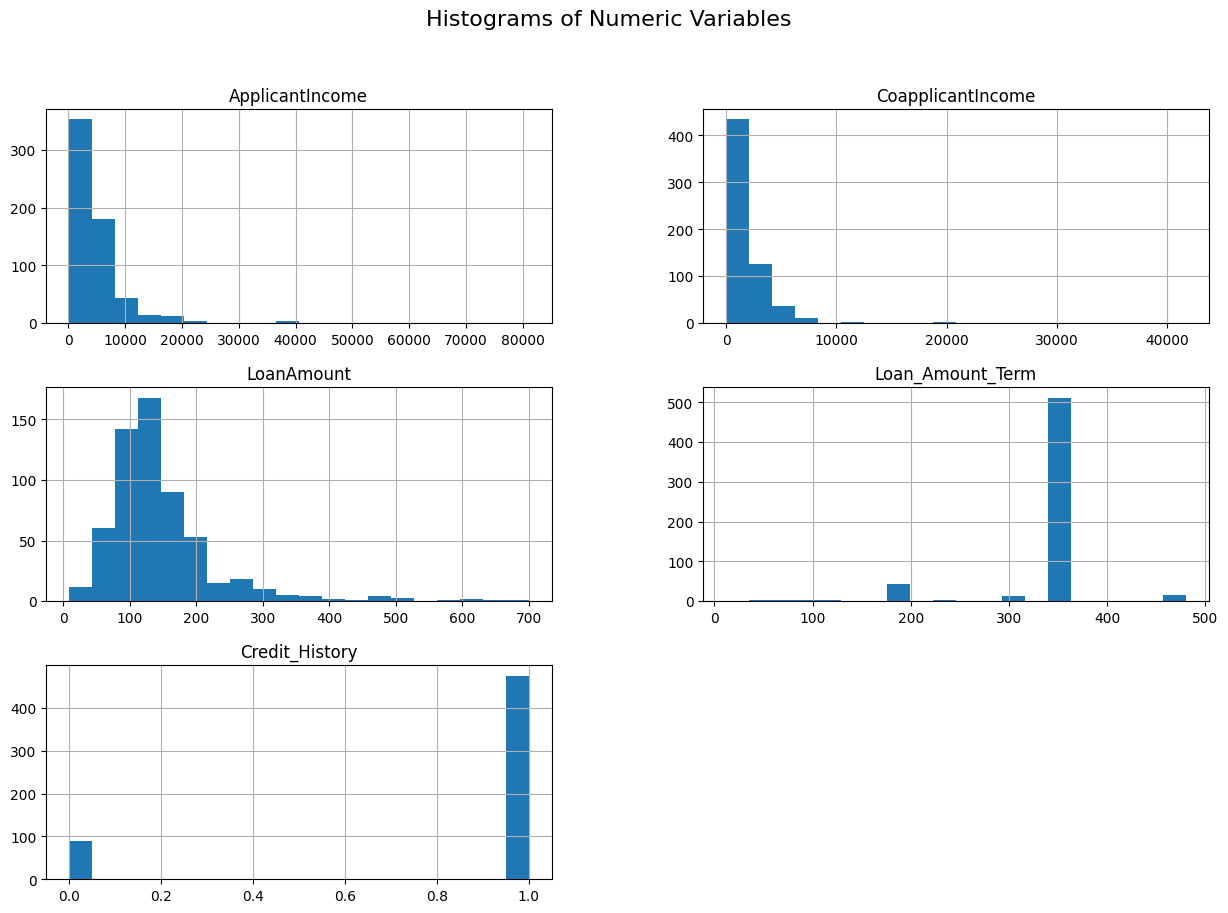

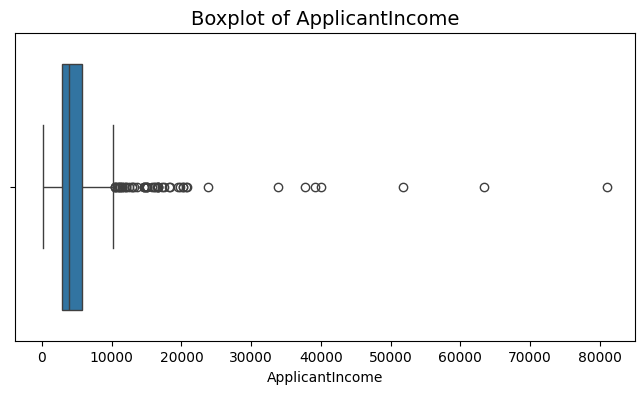

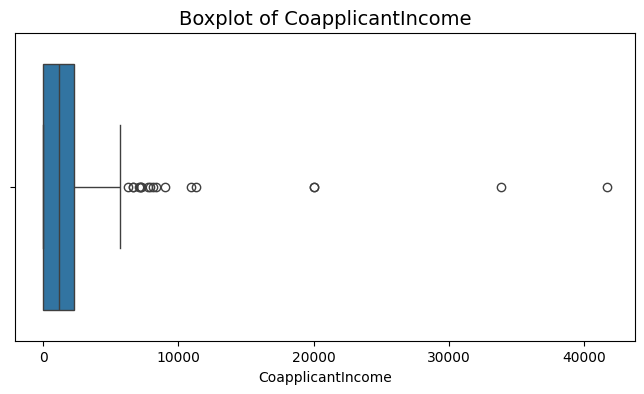

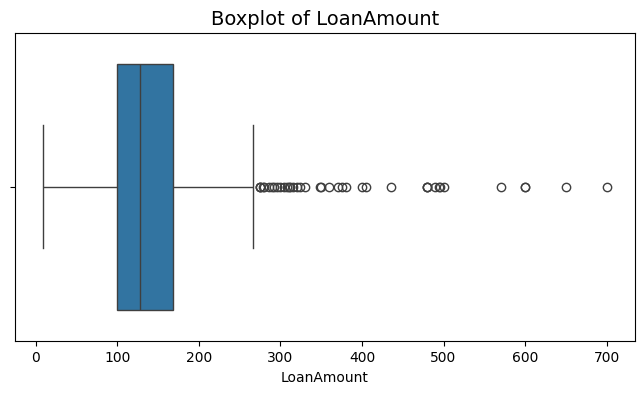

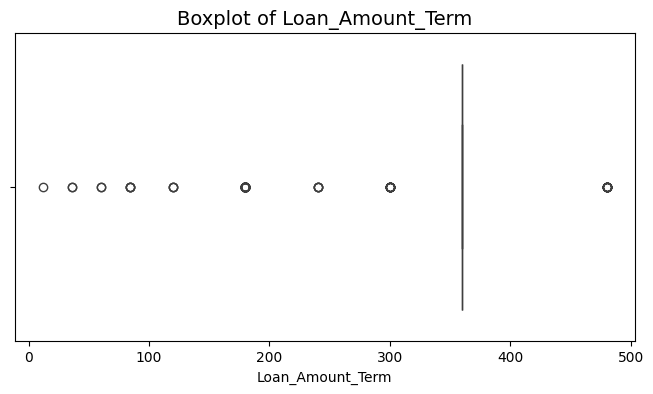

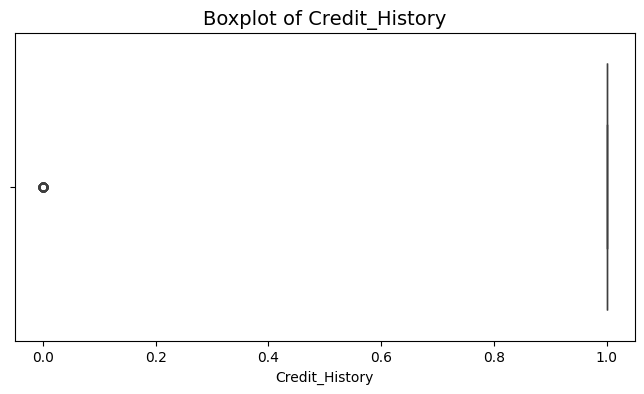

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Histogramas para variables numéricas
df.hist(bins=20, figsize=(15, 10))
plt.suptitle('Histograms of Numeric Variables', fontsize=16)
plt.show()

# Boxplots para identificar outliers
num_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']
for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}', fontsize=14)
    plt.show()


**Variables categóricas**

In [9]:
cat_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']
for col in cat_cols:
    print(f"Distribución de {col}:\n{df[col].value_counts()}\n")


Distribución de Gender:
Gender
Male      489
Female    112
Name: count, dtype: int64

Distribución de Married:
Married
Yes    398
No     213
Name: count, dtype: int64

Distribución de Dependents:
Dependents
0     345
1     102
2     101
3+     51
Name: count, dtype: int64

Distribución de Education:
Education
Graduate        480
Not Graduate    134
Name: count, dtype: int64

Distribución de Self_Employed:
Self_Employed
No     500
Yes     82
Name: count, dtype: int64

Distribución de Property_Area:
Property_Area
Semiurban    233
Urban        202
Rural        179
Name: count, dtype: int64

Distribución de Loan_Status:
Loan_Status
Y    422
N    192
Name: count, dtype: int64



**Identificar y documentar valores faltantes**

In [10]:
missing = df.isnull().sum()
missing_percentage = (missing / len(df)) * 100
print(pd.DataFrame({'Missing Values': missing, 'Percentage': missing_percentage}))


                   Missing Values  Percentage
Loan_ID                         0    0.000000
Gender                         13    2.117264
Married                         3    0.488599
Dependents                     15    2.442997
Education                       0    0.000000
Self_Employed                  32    5.211726
ApplicantIncome                 0    0.000000
CoapplicantIncome               0    0.000000
LoanAmount                     22    3.583062
Loan_Amount_Term               14    2.280130
Credit_History                 50    8.143322
Property_Area                   0    0.000000
Loan_Status                     0    0.000000


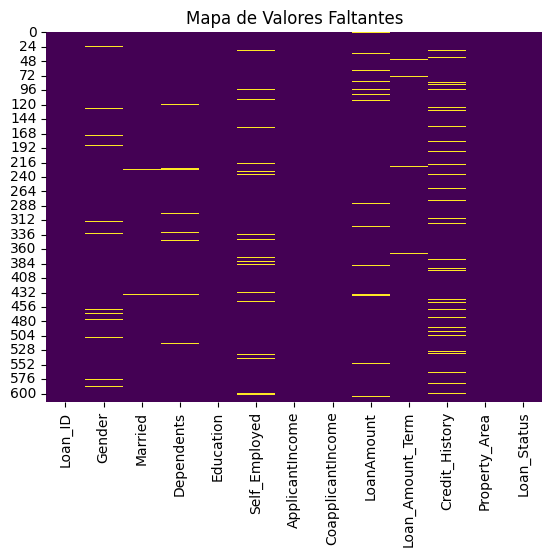

In [11]:
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Mapa de Valores Faltantes")
plt.show()

In [12]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col} tiene {len(outliers)} outliers.")


ApplicantIncome tiene 50 outliers.
CoapplicantIncome tiene 18 outliers.
LoanAmount tiene 39 outliers.
Loan_Amount_Term tiene 88 outliers.
Credit_History tiene 89 outliers.


**Parte 2: Análisis Exploratorio de Datos (EDA)**

**Análisis Estadístico Descriptivo:**
* Calcular estadísticas descriptivas básicas (media, mediana, desviación estándar, etc.).
* Analizar la distribución de las variables categóricas.


In [13]:
# Estadísticas descriptivas para las variables numéricas
print("Estadísticas descriptivas para variables numéricas:\n")
print(df.describe())

# Estadísticas descriptivas para variables categóricas
cat_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']
print("\nEstadísticas descriptivas para variables categóricas:\n")
print(df[cat_cols].describe(include='all'))


Estadísticas descriptivas para variables numéricas:

       ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
count       614.000000         614.000000  592.000000         600.00000   
mean       5403.459283        1621.245798  146.412162         342.00000   
std        6109.041673        2926.248369   85.587325          65.12041   
min         150.000000           0.000000    9.000000          12.00000   
25%        2877.500000           0.000000  100.000000         360.00000   
50%        3812.500000        1188.500000  128.000000         360.00000   
75%        5795.000000        2297.250000  168.000000         360.00000   
max       81000.000000       41667.000000  700.000000         480.00000   

       Credit_History  
count      564.000000  
mean         0.842199  
std          0.364878  
min          0.000000  
25%          1.000000  
50%          1.000000  
75%          1.000000  
max          1.000000  

Estadísticas descriptivas para variables categóricas:


In [14]:
# Moda
print(df.mode())

      Loan_ID Gender Married Dependents Education Self_Employed  \
0    LP001002   Male     Yes          0  Graduate            No   
1    LP001003    NaN     NaN        NaN       NaN           NaN   
2    LP001005    NaN     NaN        NaN       NaN           NaN   
3    LP001006    NaN     NaN        NaN       NaN           NaN   
4    LP001008    NaN     NaN        NaN       NaN           NaN   
..        ...    ...     ...        ...       ...           ...   
609  LP002978    NaN     NaN        NaN       NaN           NaN   
610  LP002979    NaN     NaN        NaN       NaN           NaN   
611  LP002983    NaN     NaN        NaN       NaN           NaN   
612  LP002984    NaN     NaN        NaN       NaN           NaN   
613  LP002990    NaN     NaN        NaN       NaN           NaN   

     ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             2500.0                0.0       120.0             360.0   
1                NaN                NaN         N

In [15]:
# Filtramos solo las columnas numéricas
numerical_cols = df.select_dtypes(include=['float64', 'int64'])

# Calcular la varianza solo sobre las columnas numéricas
print(numerical_cols.var())

ApplicantIncome      3.732039e+07
CoapplicantIncome    8.562930e+06
LoanAmount           7.325190e+03
Loan_Amount_Term     4.240668e+03
Credit_History       1.331362e-01
dtype: float64


**Análisis de la Distribución de Variables Categóricas**

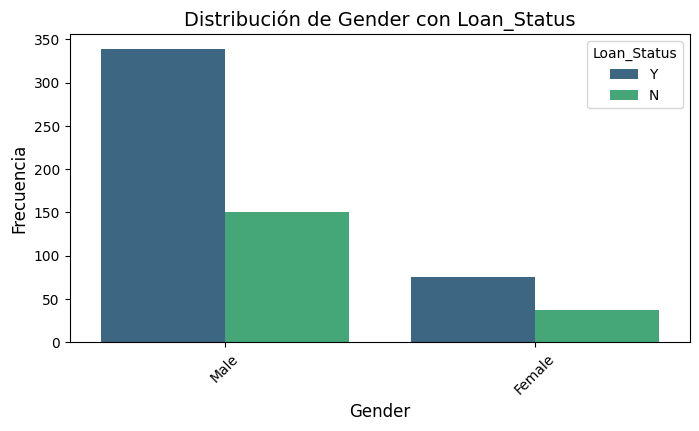

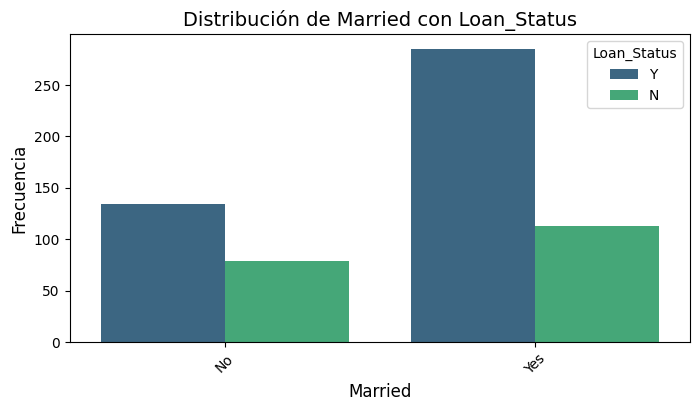

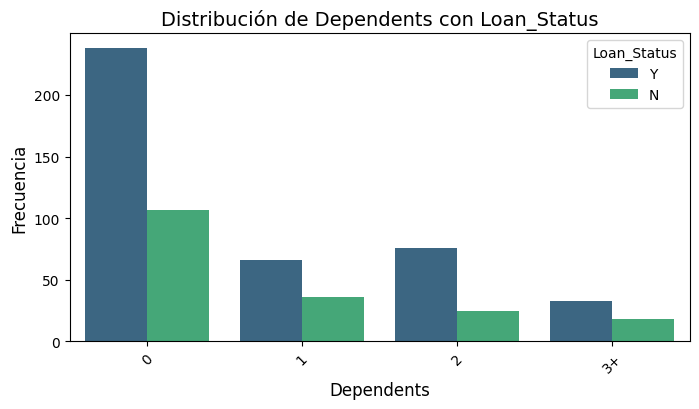

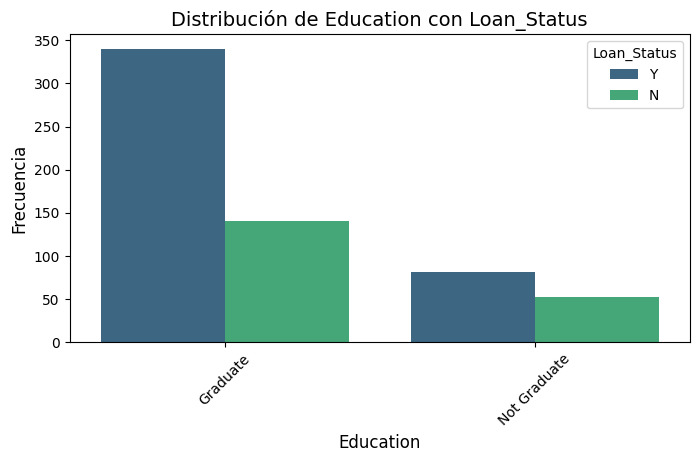

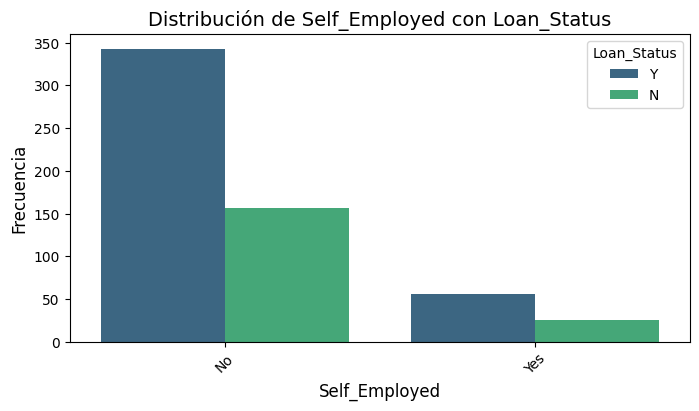

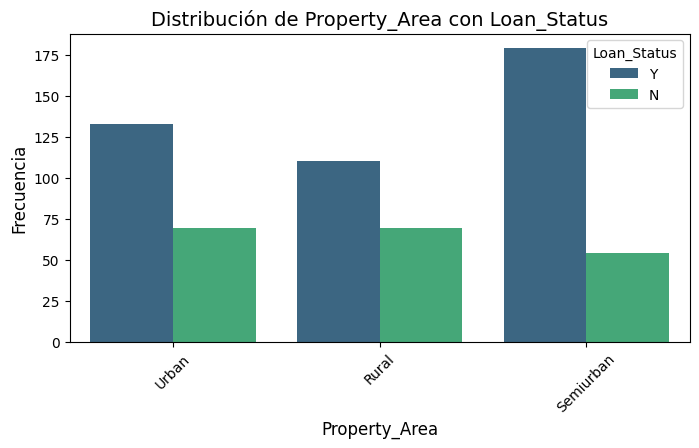

C:\Users\USER 4\AppData\Local\Temp\ipykernel_30608\588066660.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=hue_col)  # Añadir una leyenda con título


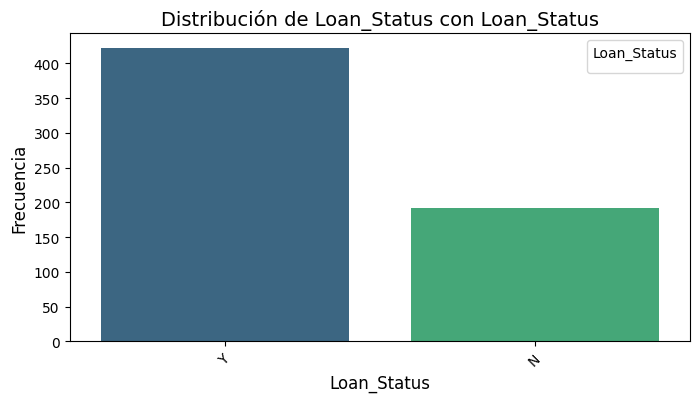

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Distribución de variables categóricas
cat_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']
hue_col = 'Loan_Status'  # Definir la columna para el hue

for col in cat_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=col, data=df, palette="viridis", hue=hue_col)
    plt.title(f"Distribución de {col} con {hue_col}", fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel("Frecuencia", fontsize=12)
    plt.xticks(rotation=45)
    plt.legend(title=hue_col)  # Añadir una leyenda con título
    plt.show()



**Visualizaciones:**
* Crear histogramas y gráficos de barras para entender la distribución de las variables.
* Crear un mapa de calor para visualizar las correlaciones entre las variables.
* Utilizar gráficos de dispersión para identificar posibles relaciones entre las variables.

**Histogramas para entender la distribución de las variables numéricas**

<Figure size 1200x1000 with 0 Axes>

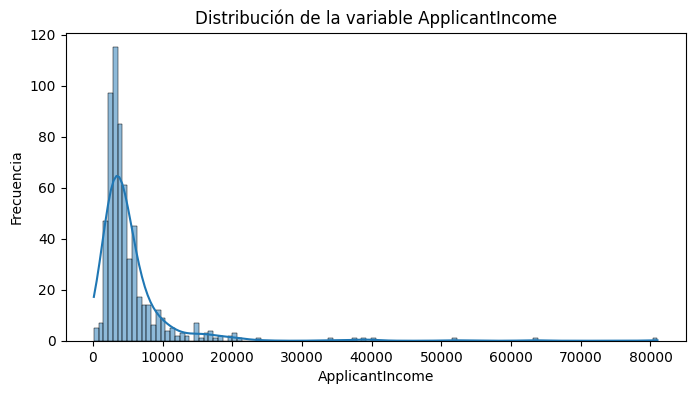

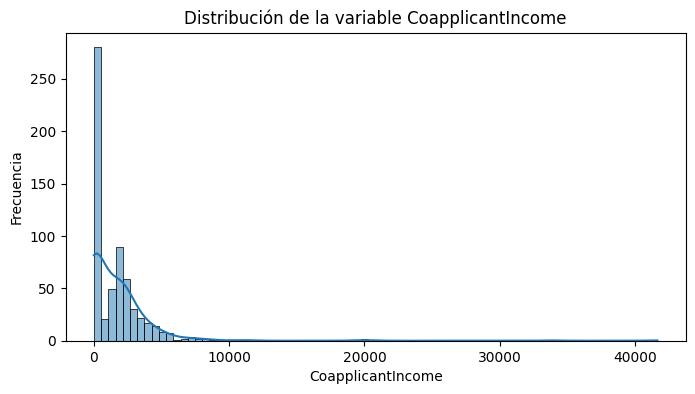

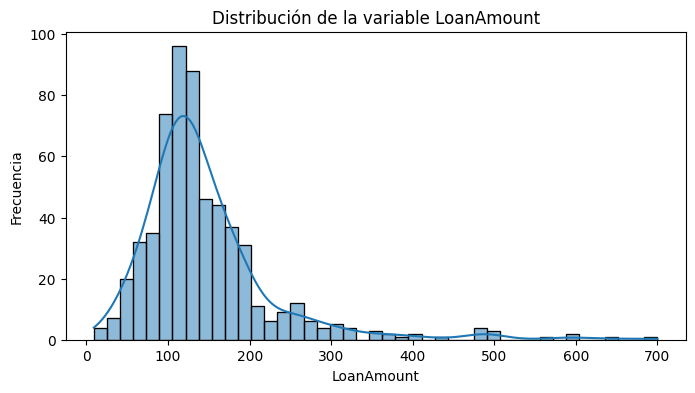

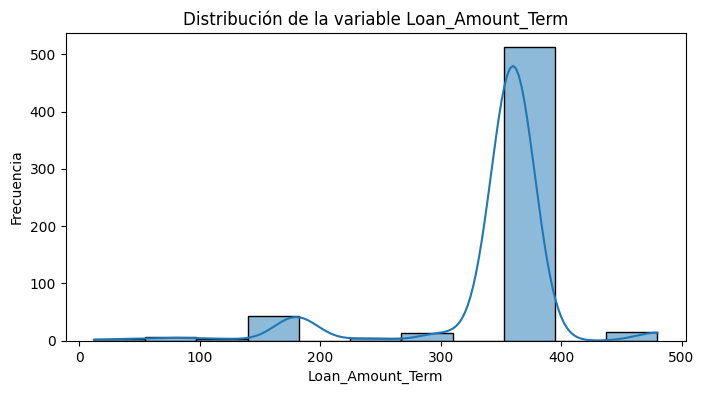

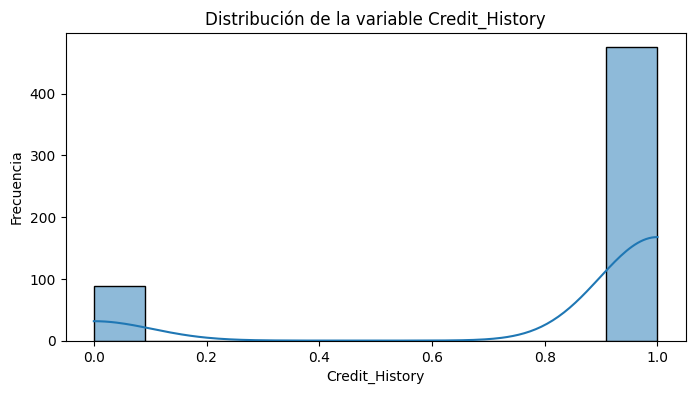

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear histogramas para todas las variables numéricas
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Configuración para las gráficas
plt.figure(figsize=(12, 10))

for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribución de la variable {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.show()


**Mapa de calor para visualizar las correlaciones entre las variables**

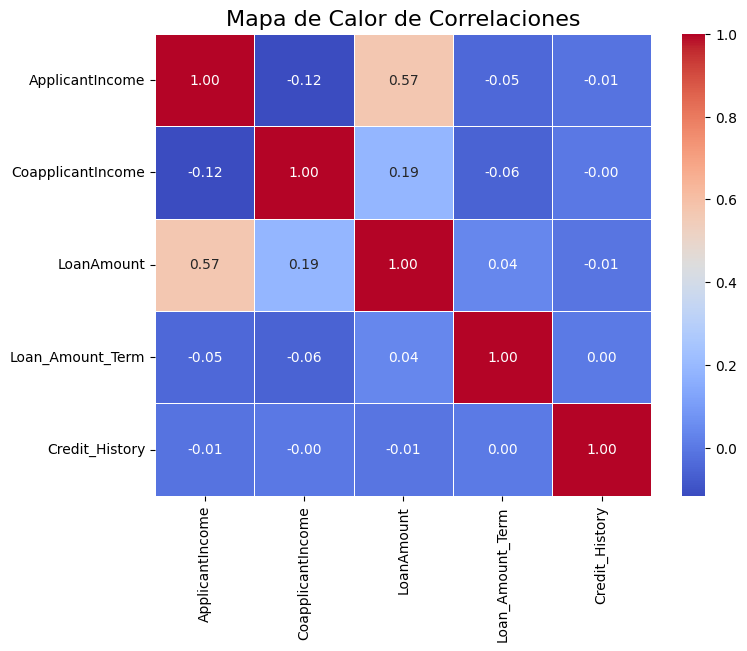

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionar las variables numéricas para calcular la correlación
num_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']

# Calcular la matriz de correlación
correlation_matrix = df[num_cols].corr()

# Generar el mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Mapa de Calor de Correlaciones", fontsize=16)
plt.show()


**Gráficos de dispersión para identificar relaciones entre variables**

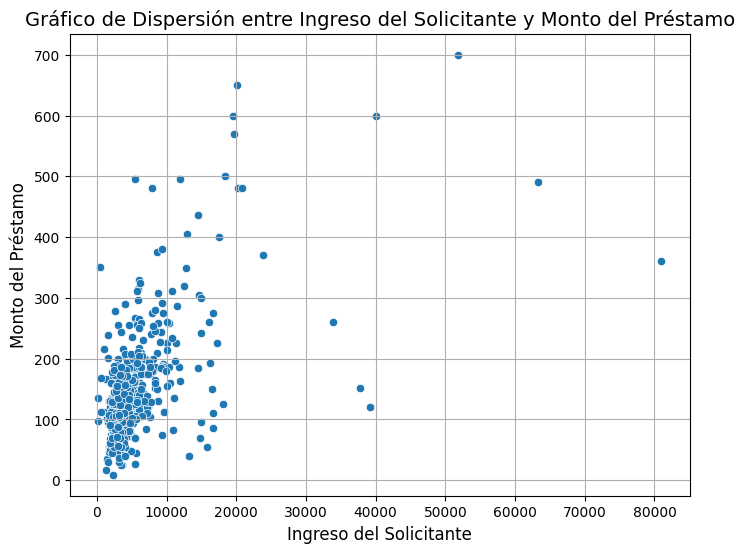

In [19]:
# Gráfico de dispersión entre dos variables numéricas (ejemplo con 'ApplicantIncome' y 'LoanAmount')
plt.figure(figsize=(8, 6))
sns.scatterplot(x='ApplicantIncome', y='LoanAmount', data=df)
plt.title('Gráfico de Dispersión entre Ingreso del Solicitante y Monto del Préstamo', fontsize=14)
plt.xlabel('Ingreso del Solicitante', fontsize=12)
plt.ylabel('Monto del Préstamo', fontsize=12)
plt.grid(True)
plt.show()


C:\Users\USER 4\AppData\Local\Temp\ipykernel_30608\2079651576.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Gender', y='ApplicantIncome', data=df, palette='viridis')


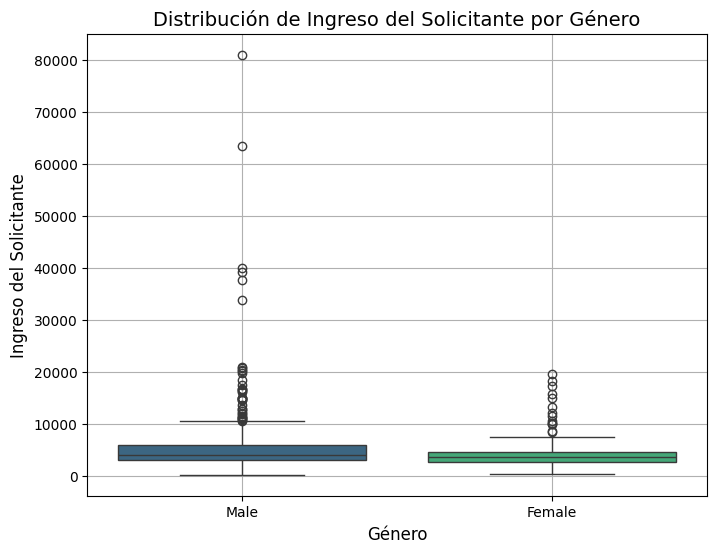

In [20]:
# Gráfico de caja entre una variable categórica y una numérica (ejemplo 'Gender' y 'ApplicantIncome')
plt.figure(figsize=(8, 6))
sns.boxplot(x='Gender', y='ApplicantIncome', data=df, palette='viridis')
plt.title('Distribución de Ingreso del Solicitante por Género', fontsize=14)
plt.xlabel('Género', fontsize=12)
plt.ylabel('Ingreso del Solicitante', fontsize=12)
plt.grid(True)
plt.show()


**Valores Faltantes y Outliers:**
* Detectar y tratar valores faltantes.
* Identificar y manejar outliers

Valores faltantes por columna:

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


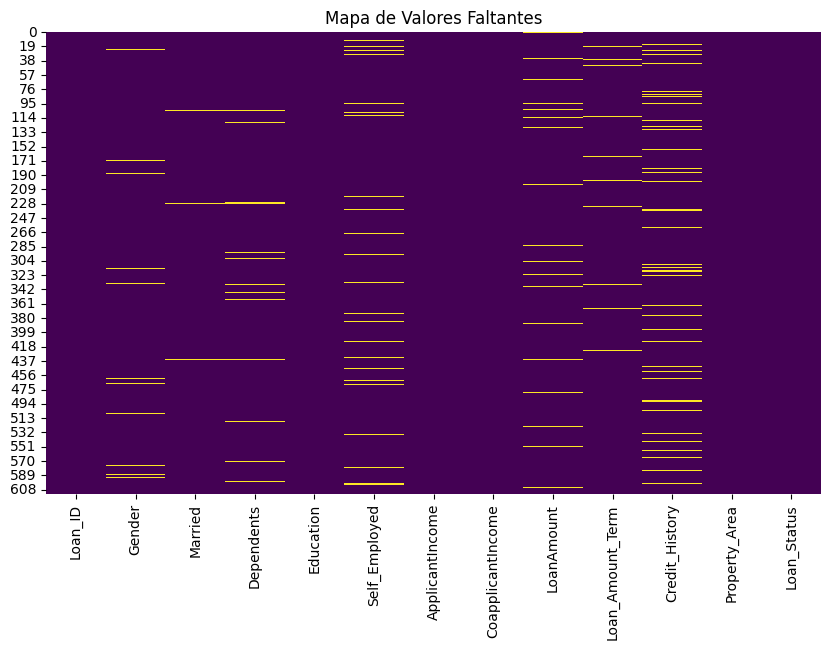

C:\Users\USER 4\AppData\Local\Temp\ipykernel_30608\351486697.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)  # Llenar con la moda
C:\Users\USER 4\AppData\Local\Temp\ipykernel_30608\351486697.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values a

In [21]:
# Resumen de valores faltantes
print("Valores faltantes por columna:\n")
print(df.isnull().sum())

# Visualización de valores faltantes
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Mapa de Valores Faltantes")
plt.show()

# Tratar valores faltantes: ejemplo con imputación
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)  # Llenar con la moda
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)  # Llenar con la mediana
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)  # Llenar con la moda


 **Identificar y Manejar Outliers**

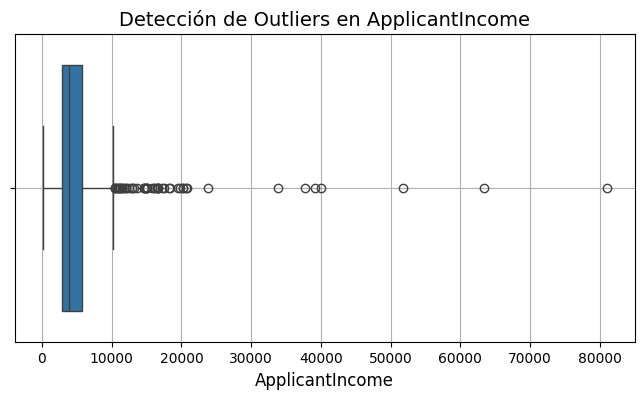

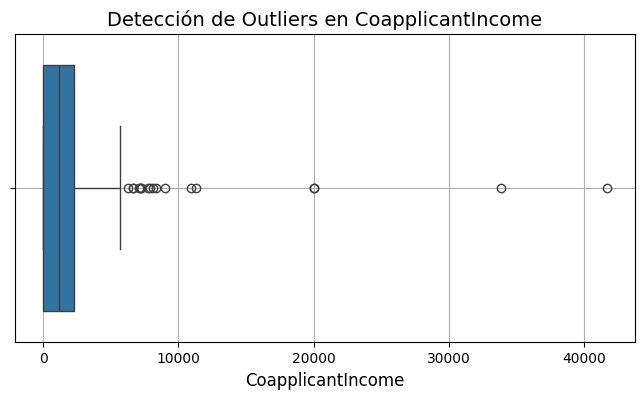

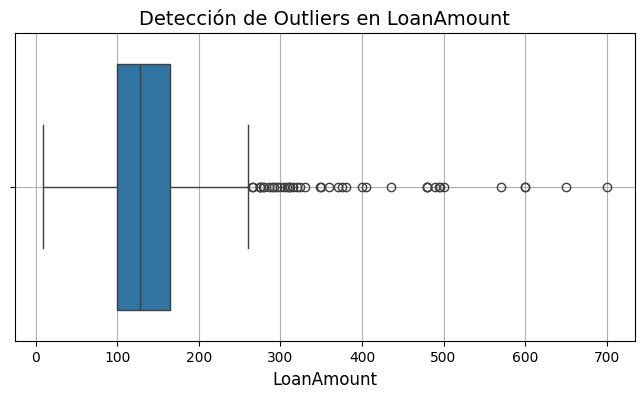

In [22]:
# Identificación de outliers mediante boxplots
num_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']
for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Detección de Outliers en {col}', fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.grid(True)
    plt.show()

# Tratamiento de outliers: Usar el rango intercuartil (IQR)
for col in num_cols:
    Q1 = df[col].quantile(0.25)  # Primer cuartil
    Q3 = df[col].quantile(0.75)  # Tercer cuartil
    IQR = Q3 - Q1  # Rango intercuartil
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Reemplazar outliers con los límites
    df[col] = df[col].apply(lambda x: lower_bound if x < lower_bound else (upper_bound if x > upper_bound else x))


**Parte 3: Preprocesamiento de Datos**

**Transformación de Columnas:**
* Codificar variables categóricas utilizando One-Hot Encoding.
* Escalar características numéricas utilizando StandardScaler.

**División del Conjunto de Datos:**
* Dividir el dataset en conjuntos de entrenamiento y prueba.

Transformación de Columnas
Codificar variables categóricas usando One-Hot Encoding

In [23]:
# Codificar variables categóricas usando One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status'], drop_first=True)

# Mostrar las primeras filas del dataframe codificado
df_encoded.head()


,Loan_ID,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban,Loan_Status_Y
0,LP001002,5849.0,0.0,128.0,360.0,1.0,True,False,False,False,False,False,False,False,True,True
1,LP001003,4583.0,1508.0,128.0,360.0,1.0,True,True,True,False,False,False,False,False,False,False
2,LP001005,3000.0,0.0,66.0,360.0,1.0,True,True,False,False,False,False,True,False,True,True
3,LP001006,2583.0,2358.0,120.0,360.0,1.0,True,True,False,False,False,True,False,False,True,True
4,LP001008,6000.0,0.0,141.0,360.0,1.0,True,False,False,False,False,False,False,False,True,True


In [24]:
from sklearn.preprocessing import StandardScaler

# Seleccionar columnas numéricas para escalar
num_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']

# Inicializar StandardScaler
scaler = StandardScaler()

# Escalar las columnas numéricas
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

# Verificar el dataframe escalado
df_encoded.head()


,Loan_ID,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban,Loan_Status_Y
0,LP001002,0.497164,-0.874587,-0.168041,0.276642,0.411733,True,False,False,False,False,False,False,False,True,True
1,LP001003,-0.013767,0.054395,-0.168041,0.276642,0.411733,True,True,True,False,False,False,False,False,False,False
2,LP001005,-0.652632,-0.874587,-1.280462,0.276642,0.411733,True,True,False,False,False,False,True,False,True,True
3,LP001006,-0.820924,0.578025,-0.311579,0.276642,0.411733,True,True,False,False,False,True,False,False,True,True
4,LP001008,0.558104,-0.874587,0.065209,0.276642,0.411733,True,False,False,False,False,False,False,False,True,True


**División del Conjunto de Datos**

In [25]:
from sklearn.model_selection import train_test_split

# Separar las características (X) y la variable objetivo (y)
X = df_encoded.drop('Loan_Status_Y', axis=1)  # 'Loan_Status_Y' es la columna binarizada (1 si es aprobado, 0 si no)
y = df_encoded['Loan_Status_Y']

# Dividir el dataset en conjuntos de entrenamiento y prueba (80% - 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verificar las dimensiones de los conjuntos
print("Conjunto de Entrenamiento:", X_train.shape)
print("Conjunto de Prueba:", X_test.shape)


Conjunto de Entrenamiento: (491, 15)
Conjunto de Prueba: (123, 15)


**Parte 4: Implementación de LightGBM (LGBM)**

**Entrenamiento del Modelo:**
* Entrenar un modelo de LGBM con hiperparámetros básicos.
* Evaluar el modelo utilizando métricas de rendimiento como la exactitud, precisión, recall, F1-Score y ROC-AUC.


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             614 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    float64
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         614 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     614 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(5), object(8)
memory usage: 62.5+ KB


In [30]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import lightgbm as lgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Paso 1: Manejar los valores nulos en 'Loan_Amount_Term'
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mean(), inplace=True)

# Paso 2: Convertir columnas categóricas a numéricas
# Identificar las columnas categóricas
categorical_columns = df.select_dtypes(include=['object']).columns

# Usar LabelEncoder para convertirlas
le = LabelEncoder()
for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

# Paso 3: Separar las características (X) y la variable objetivo (y)
X = df.drop(columns=['Loan_Status'])  # Reemplaza 'Loan_Status' por el nombre de tu variable objetivo
y = df['Loan_Status']  # Variable objetivo

# Paso 4: Escalar las características numéricas
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Paso 5: Dividir el conjunto de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Paso 6: Entrenamiento del modelo LGBM
lgbm_model = lgb.LGBMClassifier(n_estimators=100, learning_rate=0.05, max_depth=7, random_state=42)
lgbm_model.fit(X_train, y_train)

# Paso 7: Predicciones en el conjunto de prueba
y_pred = lgbm_model.predict(X_test)

# Paso 8: Evaluar el modelo utilizando varias métricas
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)

# Mostrar los resultados de las métricas
print("Exactitud:", accuracy)
print("Precisión:", precision)
print("Recall:", recall)
print("F1-Score:", f1)
print("ROC-AUC:", roc_auc)



[LightGBM] [Info] Number of positive: 342, number of negative: 149
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000170 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 513
[LightGBM] [Info] Number of data points in the train set: 491, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.696538 -> initscore=0.830864
[LightGBM] [Info] Start training from score 0.830864
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[

C:\Users\USER 4\AppData\Local\Temp\ipykernel_30608\64410480.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mean(), inplace=True)


**Optimización de Hiperparámetros:**
* Utilizar GridSearchCV para optimizar los hiperparámetros del modelo de LGBM.

Fitting 3 folds for each of 81 candidates, totalling 243 fits


C:\Users\USER 4\AppData\Roaming\Python\Python312\site-packages\numpy\ma\core.py:2881: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,
C:\Users\USER 4\AppData\Local\Temp\ipykernel_30608\2010224308.py:52: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


[LightGBM] [Info] Number of positive: 194, number of negative: 206
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000128 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1471
[LightGBM] [Info] Number of data points in the train set: 400, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.485000 -> initscore=-0.060018
[LightGBM] [Info] Start training from score -0.060018
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

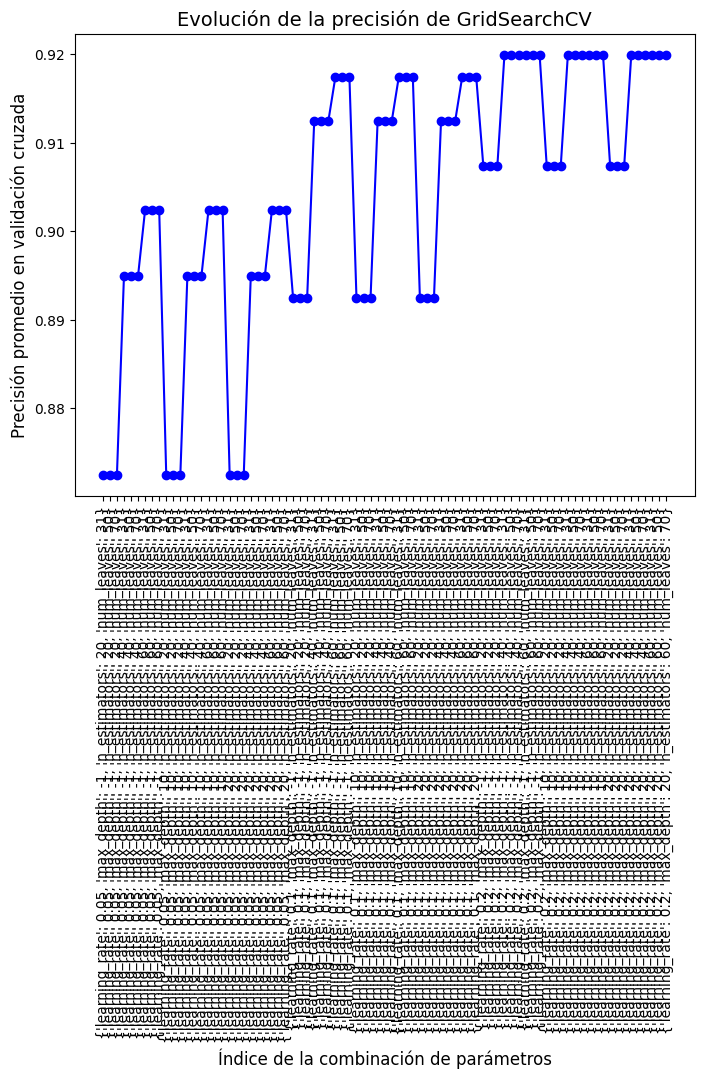

In [31]:
import lightgbm as lgb
from sklearn.model_selection import GridSearchCV, train_test_split, cross_val_score
from sklearn.datasets import make_classification
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

# Generar datos de ejemplo
X, y = make_classification(n_samples=500, n_features=11, n_classes=2, random_state=42)

# Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Definir el modelo base de LightGBM
lgbm_model = lgb.LGBMClassifier(random_state=42)

# Definir los parámetros para optimizar
param_grid = {
    'num_leaves': [31, 50, 70],
    'max_depth': [-1, 10, 20],
    'learning_rate': [0.05, 0.1, 0.2],
    'n_estimators': [20, 40, 60]
}

# Configurar el GridSearchCV
grid_search = GridSearchCV(estimator=lgbm_model, param_grid=param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)

# Ajustar el modelo con los parámetros de la búsqueda en cuadrícula
grid_search.fit(X_train, y_train)

# Ver los mejores parámetros
print("Best parameters found: ", grid_search.best_params_)

# Predecir con el modelo optimizado
y_pred = grid_search.predict(X_test)

# Evaluar el modelo
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Visualizar los resultados del GridSearchCV
results = grid_search.cv_results_
mean_test_scores = results['mean_test_score']
params = results['params']

# Visualizar la evolución de la precisión con los parámetros
plt.figure(figsize=(8, 6))
plt.plot(range(len(mean_test_scores)), mean_test_scores, marker='o', color='b')
plt.title("Evolución de la precisión de GridSearchCV", fontsize=14)
plt.xlabel("Índice de la combinación de parámetros", fontsize=12)
plt.ylabel("Precisión promedio en validación cruzada", fontsize=12)
plt.xticks(range(len(params)), [str(param) for param in params], rotation=90)
plt.tight_layout()
plt.show()


**Evaluación del Modelo Optimizado:**
* Evaluar el rendimiento del modelo optimizado y compararlo con el modelo inicial.

In [32]:
# Crear y entrenar el modelo sin optimizar
lgbm_model_initial = lgb.LGBMClassifier(random_state=42)
lgbm_model_initial.fit(X_train, y_train)

# Predecir con el modelo inicial
y_pred_initial = lgbm_model_initial.predict(X_test)

# Evaluar el modelo inicial
from sklearn.metrics import classification_report, accuracy_score

print("Initial Model - Accuracy: ", accuracy_score(y_test, y_pred_initial))
print("Initial Model - Classification Report:")
print(classification_report(y_test, y_pred_initial))


[LightGBM] [Info] Number of positive: 194, number of negative: 206
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000125 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1471
[LightGBM] [Info] Number of data points in the train set: 400, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.485000 -> initscore=-0.060018
[LightGBM] [Info] Start training from score -0.060018
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

In [33]:
# Obtener el mejor modelo desde el GridSearchCV
best_model = grid_search.best_estimator_

# Predecir con el modelo optimizado
y_pred_optimized = best_model.predict(X_test)

# Evaluar el modelo optimizado
print("Optimized Model - Accuracy: ", accuracy_score(y_test, y_pred_optimized))
print("Optimized Model - Classification Report:")
print(classification_report(y_test, y_pred_optimized))


Optimized Model - Accuracy:  0.95
Optimized Model - Classification Report:
              precision    recall  f1-score   support

           0       0.90      1.00      0.95        47
           1       1.00      0.91      0.95        53

    accuracy                           0.95       100
   macro avg       0.95      0.95      0.95       100
weighted avg       0.95      0.95      0.95       100



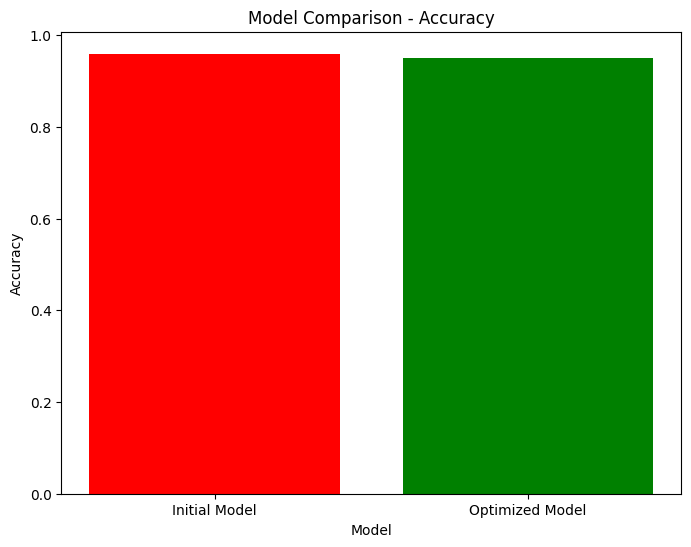

In [34]:
import matplotlib.pyplot as plt

# Métricas a comparar
accuracies = [
    accuracy_score(y_test, y_pred_initial), 
    accuracy_score(y_test, y_pred_optimized)
]
models = ['Initial Model', 'Optimized Model']

# Crear gráfico
plt.figure(figsize=(8, 6))
plt.bar(models, accuracies, color=['red', 'green'])
plt.title('Model Comparison - Accuracy')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.show()


Fitting 3 folds for each of 81 candidates, totalling 243 fits
[LightGBM] [Info] Number of positive: 194, number of negative: 206
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000114 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1471
[LightGBM] [Info] Number of data points in the train set: 400, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.485000 -> initscore=-0.060018
[LightGBM] [Info] Start training from score -0.060018
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


C:\Users\USER 4\AppData\Roaming\Python\Python312\site-packages\numpy\ma\core.py:2881: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


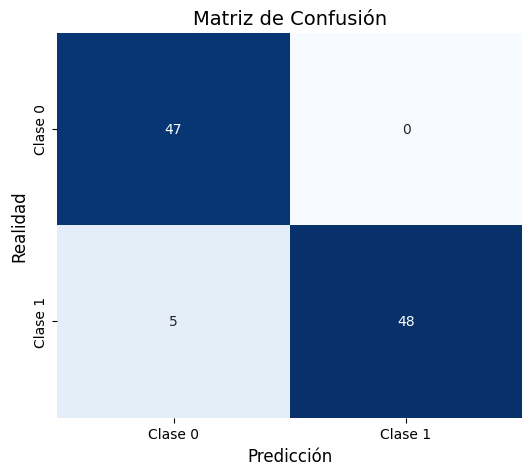

In [35]:
import lightgbm as lgb
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.datasets import make_classification
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generar datos de ejemplo
X, y = make_classification(n_samples=500, n_features=11, n_classes=2, random_state=42)

# Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Definir el modelo base de LightGBM
lgbm_model = lgb.LGBMClassifier(random_state=42)

# Definir los parámetros para optimizar
param_grid = {
    'num_leaves': [31, 50, 70],
    'max_depth': [-1, 10, 20],
    'learning_rate': [0.05, 0.1, 0.2],
    'n_estimators': [20, 40, 60]
}

# Configurar el GridSearchCV
grid_search = GridSearchCV(estimator=lgbm_model, param_grid=param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)

# Ajustar el modelo con los parámetros de la búsqueda en cuadrícula
grid_search.fit(X_train, y_train)

# Ver los mejores parámetros
print("Best parameters found: ", grid_search.best_params_)

# Predecir con el modelo optimizado
y_pred = grid_search.predict(X_test)

# Evaluar el modelo
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)

# Visualizar la matriz de confusión con seaborn
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['Clase 0', 'Clase 1'], yticklabels=['Clase 0', 'Clase 1'])
plt.title('Matriz de Confusión', fontsize=14)
plt.xlabel('Predicción', fontsize=12)
plt.ylabel('Realidad', fontsize=12)
plt.show()


# Análisis de Dataset con LightGBM

## Objetivo
El objetivo de este análisis es entrenar y optimizar un modelo de clasificación utilizando el algoritmo LightGBM sobre un conjunto de datos sintético generado. El proceso incluye la búsqueda de los mejores hiperparámetros para el modelo, evaluación mediante el reporte de clasificación y visualización de la matriz de confusión.

## Pasos Realizados

### 1. **Generación de Datos**
Se generaron datos sintéticos utilizando `make_classification` de `sklearn` para crear un dataset de 500 muestras con 11 características y 2 clases.

```python
X, y = make_classification(n_samples=500, n_features=11, n_classes=2, random_state=42)
